## **Основы и фукнции Matplotlib**

В данной библиотеке есть 2 метода, позволяющие рисовать одни и те же графики:

- Функциональный метод
- Метод объектно-ориентированного программирования

Мы будем решать 2 задачи:
1) Нарисовать функциональную связь переменных:
   - $y=2x$
2) Нарисовать график на основе набора точек:
   - $x=[1,2,3,4]$
   - $y=[2,4,6,8]$

In [24]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
x = np.arange(0,10)
y= 2 * x

In [5]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
y

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

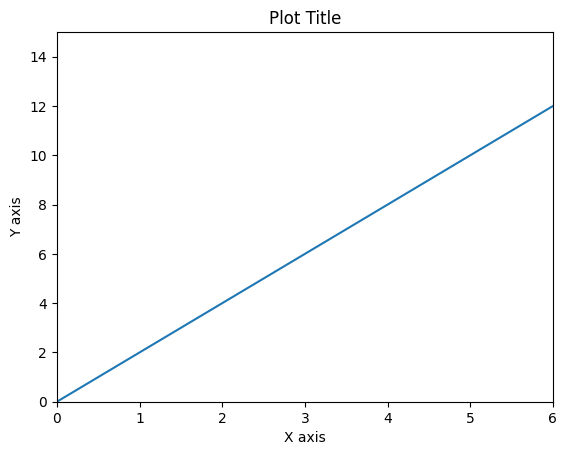

In [13]:
plt.plot(x,y)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.xlim(0,6)
plt.ylim(0,15)
plt.title('Plot Title')
plt.savefig('MyFirstPlot.png')

**plt.Figure**

Пустое пространство, на которое можно наносить оси/пары осей и другие элементы. Сразу после вызова это просто пустое пространство

In [16]:
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

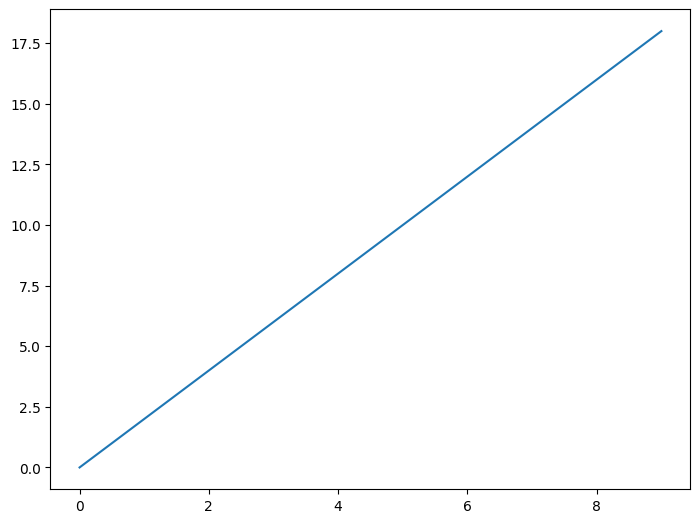

In [21]:
fig = plt.figure()
axes = fig.add_axes([0,0,1,1])
# 0,0 - начало осей относительно Figure. 0,0 - нижний левый угол. Тогда 0,1 - левый верхний и т.п.
# 1,1 - ширина и высота осей. 1,1 - 100% доля от Figure
axes.plot(x,y)

In [25]:
a = np.linspace(0,10,11)
b=a**4

In [26]:
a

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [27]:
b

array([0.000e+00, 1.000e+00, 1.600e+01, 8.100e+01, 2.560e+02, 6.250e+02,
       1.296e+03, 2.401e+03, 4.096e+03, 6.561e+03, 1.000e+04])

In [28]:
x = np.arange(0,10)
y= 2 * x

Как убрать сообщение [<matplotlib.lines.Line2D at 0x180aefac2d0>] сверху графика?
1) добавить ; после plot()
2) вызвать plt.show()

*! Вызов команды plt.show() является обязательным при работе со скриптами .py. Без этой команды график просто не отобразится. В юпитере же график сам выведется в отдельной ячейке.*

Text(0.5, 1.0, 'Увеличенный фрагмент')

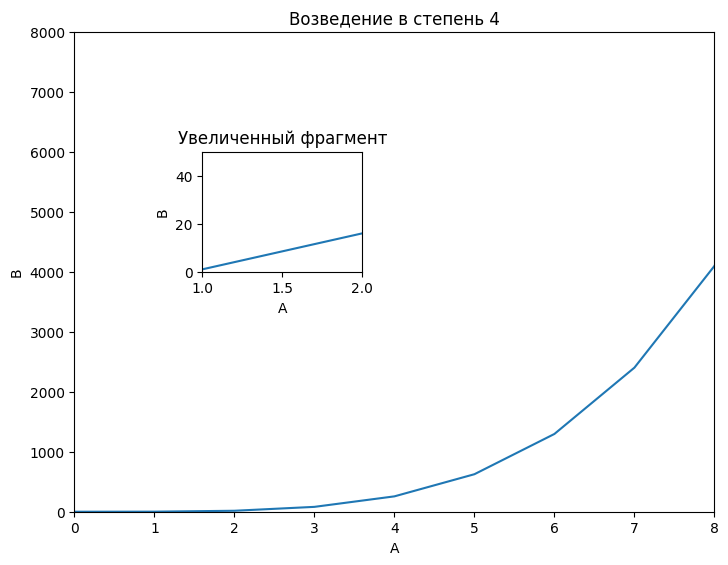

In [57]:
fig = plt.figure()

# набор больших осей
axes1 = fig.add_axes([0,0,1,1])
axes1.plot(a,b)
axes1.set_xlim(0,8)
axes1.set_ylim(0,8000)
axes1.set_xlabel('A')
axes1.set_ylabel('B')
axes1.set_title('Возведение в степень 4')

# набор маленьких осей
axes2 = fig.add_axes([0.2,0.5,0.25,0.25]) # ширина обеих осей (ширина и высота) равна половине ширины объекта figure
axes2.plot(a,b)

axes2.set_xlim(1,2)
axes2.set_ylim(0,50)
axes2.set_xlabel('A')
axes2.set_ylabel('B')
axes2.set_title('Увеличенный фрагмент')
# мы не ограничены размерами Figure. Можно указывать в set_axes любые значения
#axes3 = fig.add_axes([1,1,1.5,1.5])

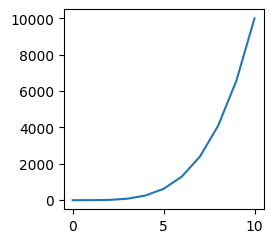

In [56]:
fig = plt.figure(figsize=(2,2),dpi=100) # DPI (Dots Per Inch)

axes1 = fig.add_axes([0,0,1,1])
axes1.plot(a,b)

fig.savefig('new_figure.png', bbox_inches='tight')
# вокруг картинки figure есть bounding box. указывая bbox_inches='tight', он подстроится под график так, чтобы не обрезать оси
#  график сохранился в той же директории, где лежит рабочий файл
# если используется Plt.show(), то если его не убрать при сохранении в картинку, картинка будет пустой! 

**plt.subplots()**

plt.subplots() позволяет создавать объекты figure, axes так, чтобы оси находились рядом друг с другом

plt.subplots() возвращает кортеж, в котором находятся объект figure и массив numpy с объектами axes

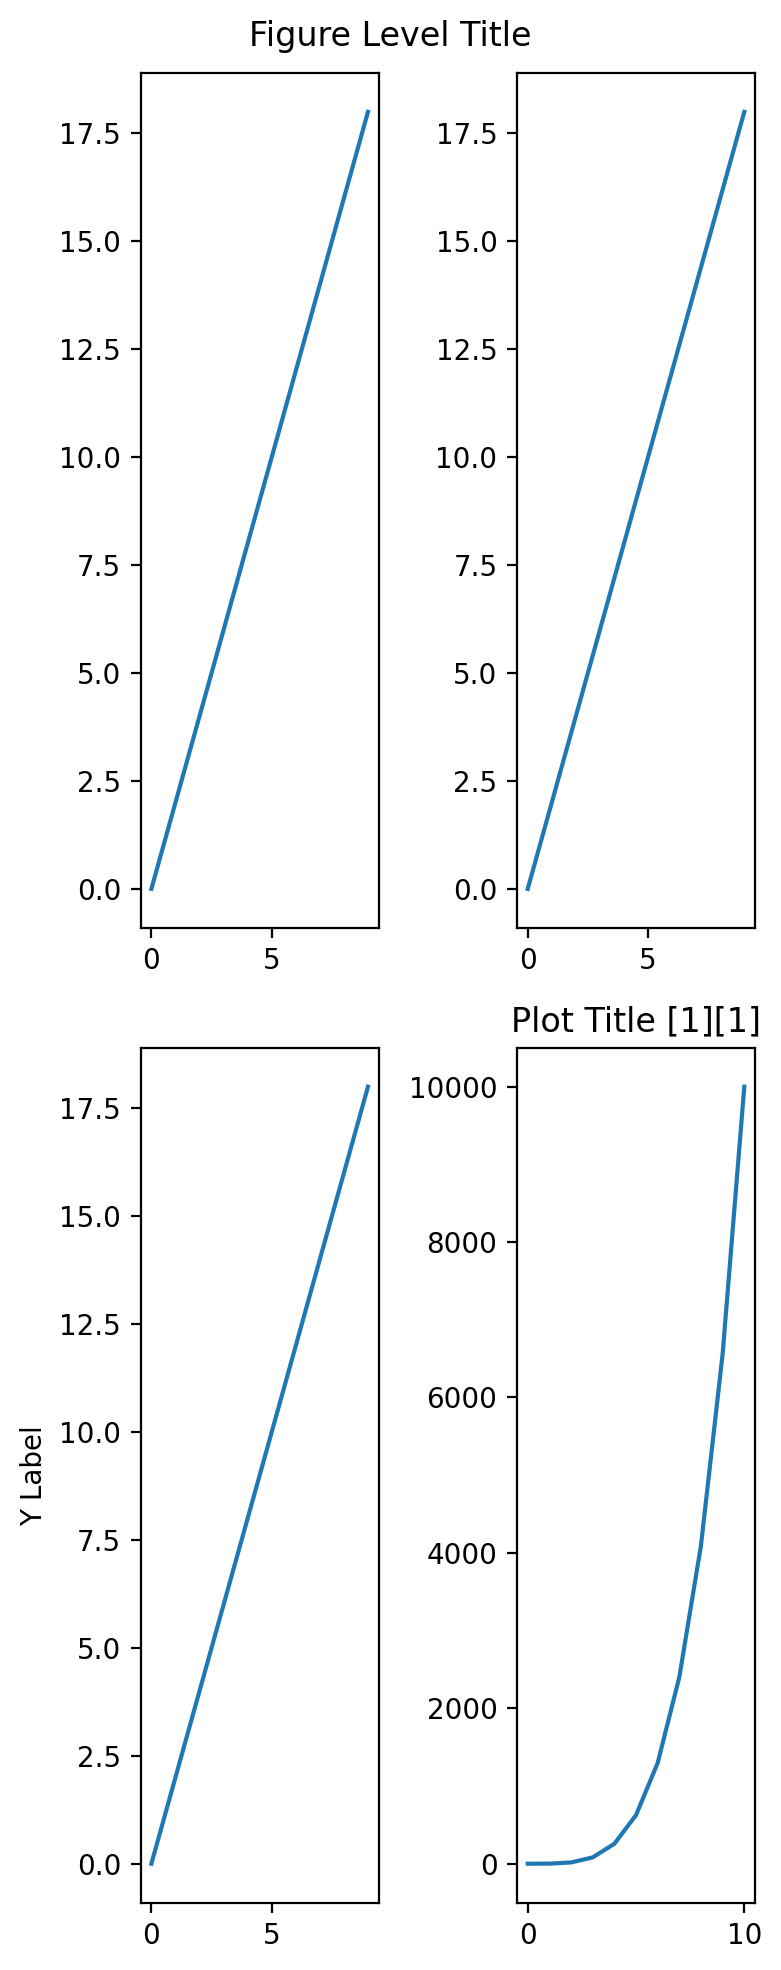

In [94]:
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(4,10), dpi=200)
axes[0][0].plot(x,y)

axes[0][1].plot(x,y)

axes[1][0].plot(x,y)
axes[1][0].set_ylabel('Y Label')

axes[1][1].plot(a,b)
axes[1][1].set_title('Plot Title [1][1]')

fig.suptitle('Figure Level Title')

plt.tight_layout()
# fig.set_figwidth(10)
fig.savefig('new_subplots.png', bbox_inches='tight')

In [68]:
type(axes)


numpy.ndarray

matplotlib.axes._axes.Axes = type(axes) если толко одна пара осей

numpy.ndarray - если осей больше

In [77]:
axes.shape
# (2,)одномерный массив из 2 эл-ов: один для пары осей слева и 1 для пары осей справа, axes[0]
# массив будет одномерным, если для ncols\nrows указано 1!
# (2,2) двумерный массив, axis[0,0]

(2, 2)

In [78]:
axes

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

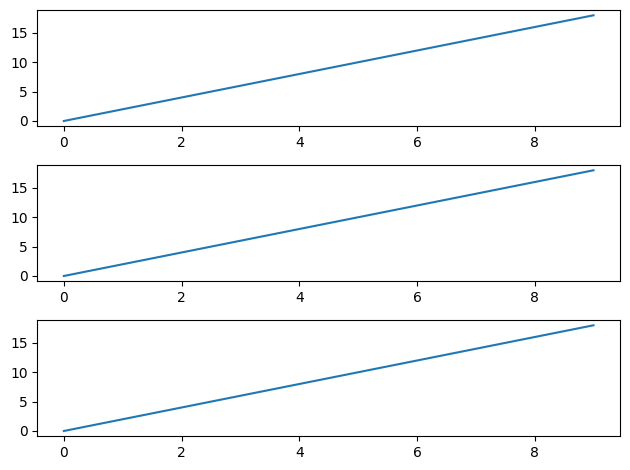

In [85]:
fig, axes = plt.subplots(3,1)

for ax in axes:
    ax.plot(x,y)
plt.tight_layout()

In [80]:
axes.shape

(3,)

In [81]:
axes

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

Как сделать так, чтобы графики не накладывались друг на друга?

1) fig.subplots_adjust(параметры)
2) plt.tight_layout()

## **Стилизация Matplotlib**

**Легенда**

Описание того, какая линия каким данным соответствует

Легенда = Визуализация всех label= на графике

Без label → нет в легенде

Удобна, если на одной паре осей больше двух графиков. Чтобы было понятно, какой график чему соответствует

ax.legend(loc=)
1) 'lower left', 'best', 'upper right',.. - словами
2) 0,1,2, .. - номером, чему какой номер соответсвует написано в документации
3) (num1, num2) - кортежем из координат левого нижнего угла легенды. Логика такая же, как и в axes = fig.add_axes([n1,n2,n3,n4]). Т.е. можно даже отрицательные числа или числа >1

По умолчанию легенда располагается как loc='best'

In [95]:
x = np.linspace(0,11,10)

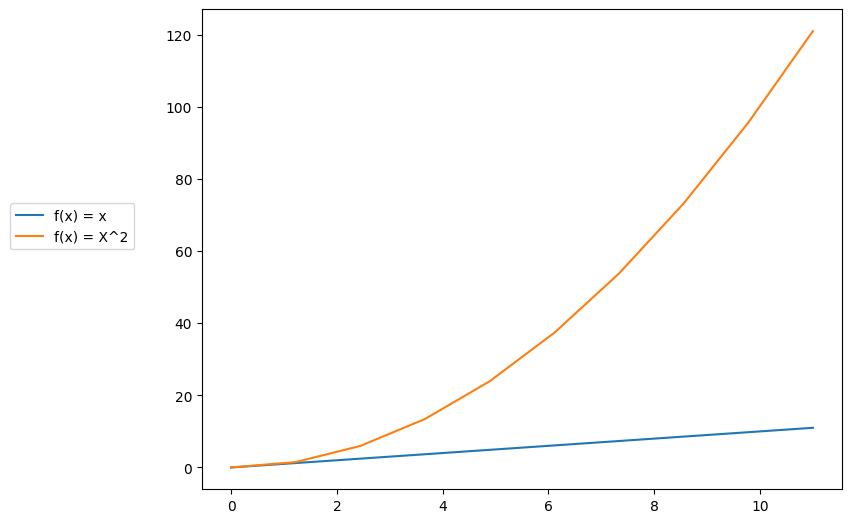

In [105]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])

ax.plot(x,x, label='f(x) = x')

ax.plot(x, x**2, label='f(x) = X^2')

ax.legend(loc=(-0.3, 0.5))

**Цвета и стили**

Это не линия, а набор точек, соединенных линией. Сами точки можно нарисовать на графике

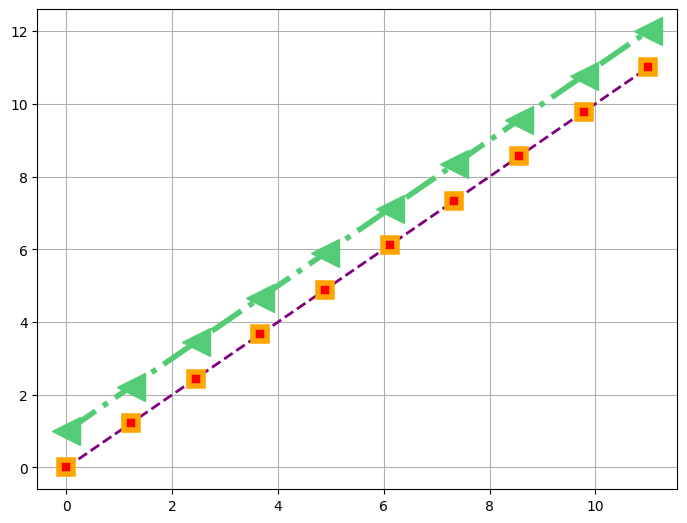

In [132]:
fig = plt.figure()

ax = fig.add_axes([0,0,1,1])

ax.plot(x, x+1, color='#54cc76', label=r'$y=x+1$', linewidth=4, linestyle='-.', marker='<', markersize=20)

ax.plot(x,x, color='purple', lw=2, marker='s', ls='--', ms=10,
       markerfacecolor='red', markeredgewidth=4, markeredgecolor='orange'
       ) 
ax.grid(True)
#ax.grid(linestyle='--', lw=0.7, color='grey', alpha=0.7)

Как еще можно задать стиль линии?

lines = ax.plot(x,x, color='#7242f5', lw=5)

lines[0].set_dashes([1,1,5,5,4,4])

1 точку нарисовали 1 пропустили. 5 точек нарисовали 5 пропустили. 4 точки нарисовали 4 пропустили. поэтому тут парами числа задаются. далее повторяются парами

ax.plot(x, x+1, color='#54cc76', label=r'$y=x+1$', linewidth=8, linestyle='-.')

In [117]:
type(lines)

list